# Boston Housing Analysis — Insights for Housing Agency Management

**Scenario:** As a Data Scientist for a Boston, MA housing agency, this notebook analyzes
U.S. Census housing data to answer four management questions:

1. Does bordering the Charles River affect median home value (MEDV)?
2. How does MEDV vary with the proportion of homes built before 1940 (AGE)?
3. Is there a relationship between Nitric Oxide levels (NOX) and non-retail business acreage (INDUS)?
4. What is the impact of distance to Boston employment centers (DIS) on MEDV?

Run cells top-to-bottom (`Runtime > Run all` in Colab).


## Setup: Import Libraries

In [1]:
# Install/upgrade packages (usually already present in Colab)
!pip install -q pandas numpy matplotlib seaborn scipy statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## Load the Dataset

We load the classic Boston Housing dataset (506 rows, 14 columns) directly from a
public CSV mirror on GitHub. This works out of the box on Colab since it has internet access.

**Column reference:**
| Column | Meaning |
|---|---|
| CRIM | per-capita crime rate by town |
| ZN | proportion of residential land zoned for large lots |
| INDUS | proportion of non-retail business acres per town |
| CHAS | Charles River dummy variable (1 = tract bounds river, 0 = otherwise) |
| NOX | nitric oxide concentration (parts per 10 million) |
| RM | average number of rooms per dwelling |
| AGE | proportion of owner-occupied units built before 1940 |
| DIS | weighted distances to five Boston employment centers |
| RAD | index of accessibility to radial highways |
| TAX | property tax rate per $10,000 |
| PTRATIO | pupil-teacher ratio by town |
| B | 1000(Bk - 0.63)^2, where Bk is the proportion of Black residents by town |
| LSTAT | % lower status of the population |
| MEDV | median value of owner-occupied homes, in $1000s (target variable) |


In [2]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

# Standardize column names to uppercase to match the classic naming convention
df.columns = [c.upper() for c in df.columns]

print(f"Shape: {df.shape}")
df.head()


Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


---
# Task 1: Familiarize Yourself with the Dataset


### 1.1 First 5 rows

In [3]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


### 1.2 Data types of each column

In [4]:
df.dtypes

,0
CRIM,float64
ZN,float64
INDUS,float64
CHAS,int64
NOX,float64
RM,float64
AGE,float64
DIS,float64
RAD,int64
TAX,int64


### 1.3 Missing values per column

In [5]:
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values in dataset: {missing.sum()}")


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Total missing values in dataset: 0


### 1.4 Duplicate rows

In [6]:
dupes = df.duplicated().sum()
print(f"Number of duplicate rows: {dupes}")


Number of duplicate rows: 0


### 1.5 Correlation matrix

In [7]:
corr = df.corr()
corr


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


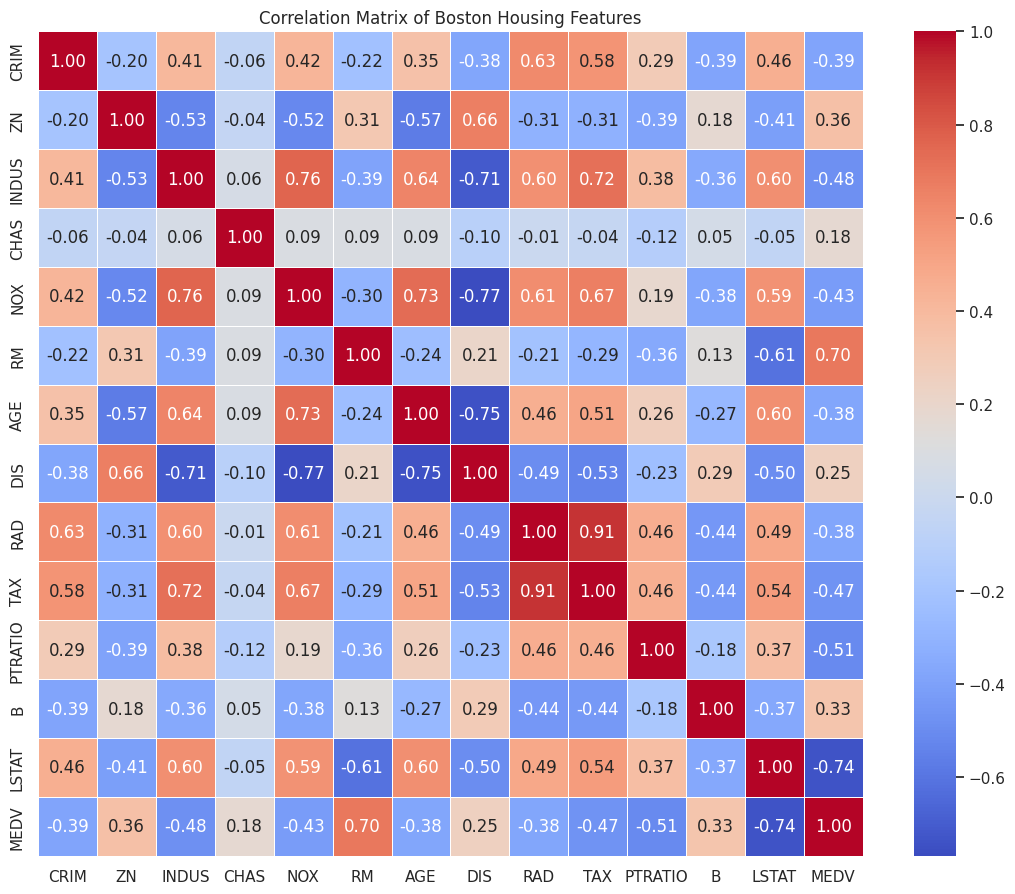

In [8]:
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Matrix of Boston Housing Features")
plt.tight_layout()
plt.show()


**Interpretation:** `LSTAT` (-0.74) and `RM` (+0.70) show the strongest correlations with `MEDV`.
`NOX` and `INDUS` are strongly positively correlated (~0.76), which we investigate further in Task 3.
`DIS` is negatively correlated with `MEDV` (-0.25) and strongly negatively correlated with `NOX` and `AGE`,
consistent with older, more industrial/polluted areas being closer to the city center.

---
# Task 2: Generate Descriptive Statistics and Visualizations


### 2.1 Descriptive statistics

In [9]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### 2.2 Boxplot for MEDV

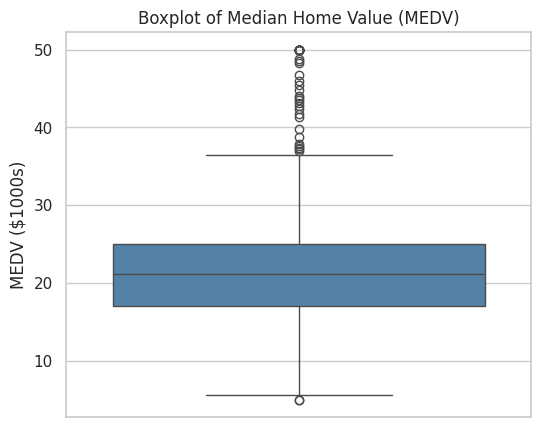

Median MEDV: 21.20
Number of potential outliers (above upper whisker): 38


In [10]:
plt.figure(figsize=(6, 5))
sns.boxplot(y=df["MEDV"], color="steelblue")
plt.title("Boxplot of Median Home Value (MEDV)")
plt.ylabel("MEDV ($1000s)")
plt.show()

print(f"Median MEDV: {df['MEDV'].median():.2f}")
print(f"Number of potential outliers (above upper whisker): "
      f"{(df['MEDV'] > df['MEDV'].quantile(0.75) + 1.5*(df['MEDV'].quantile(0.75)-df['MEDV'].quantile(0.25))).sum()}")


**Interpretation:** Median home values cluster mostly between \$17k and \$25k (in 1970s dollars, ×1000),
with a cluster of high-value outliers at the \$50k cap — likely a data-capping artifact in the original
census collection rather than a true price ceiling.

### 2.3 Bar plot for CHAS (Charles River dummy variable)

/tmp/ipykernel_825/346504390.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=chas_counts.index.astype(str), y=chas_counts.values, palette="Blues_d")


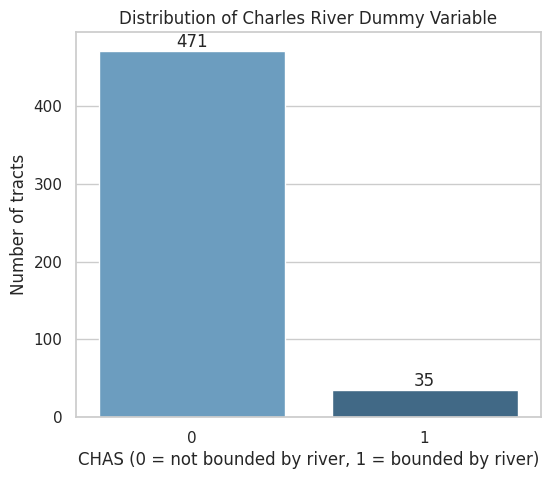

CHAS
0    471
1     35
Name: count, dtype: int64


In [11]:
chas_counts = df["CHAS"].value_counts().sort_index()

plt.figure(figsize=(6, 5))
sns.barplot(x=chas_counts.index.astype(str), y=chas_counts.values, palette="Blues_d")
plt.xlabel("CHAS (0 = not bounded by river, 1 = bounded by river)")
plt.ylabel("Number of tracts")
plt.title("Distribution of Charles River Dummy Variable")
for i, v in enumerate(chas_counts.values):
    plt.text(i, v + 5, str(v), ha="center")
plt.show()

print(chas_counts)


**Interpretation:** The vast majority of census tracts (about 93%) do **not** border the Charles River,
so any comparison of river-adjacent vs. non-river-adjacent homes will involve a small, unbalanced group.

### 2.4 Discretize AGE into three groups; boxplot of MEDV vs. AGE group

/tmp/ipykernel_825/884192928.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="AGE_GROUP", y="MEDV", data=df, palette="viridis")


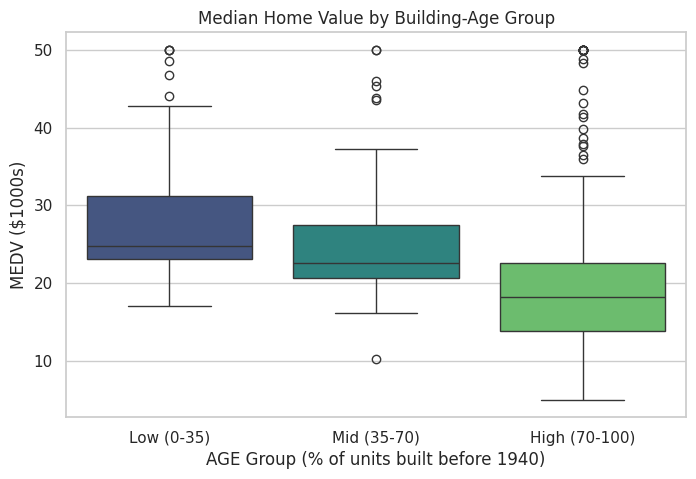

/tmp/ipykernel_825/884192928.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AGE_GROUP")["MEDV"].describe()


,count,mean,std,min,25%,50%,75%,max
AGE_GROUP,,,,,,,,
Low (0-35),91.0,27.775824,7.638198,17.1,23.050,24.8,31.150,50.0
Mid (35-70),128.0,24.947656,6.969370,10.2,20.675,22.6,27.425,50.0
High (70-100),287.0,19.793380,9.515375,5.0,13.800,18.2,22.550,50.0


In [12]:
# AGE = % of owner-occupied units built before 1940
df["AGE_GROUP"] = pd.cut(
    df["AGE"],
    bins=[0, 35, 70, 100],
    labels=["Low (0-35)", "Mid (35-70)", "High (70-100)"],
    include_lowest=True
)

plt.figure(figsize=(8, 5))
sns.boxplot(x="AGE_GROUP", y="MEDV", data=df, palette="viridis")
plt.xlabel("AGE Group (% of units built before 1940)")
plt.ylabel("MEDV ($1000s)")
plt.title("Median Home Value by Building-Age Group")
plt.show()

df.groupby("AGE_GROUP")["MEDV"].describe()


**Interpretation:** Tracts with a **low** proportion of pre-1940 buildings (newer housing stock) tend
to have noticeably higher median values, while tracts dominated by older buildings (High AGE group) show
lower and more tightly clustered median values — consistent with newer construction commanding a price premium.

### 2.5 Scatter plot: NOX vs. INDUS

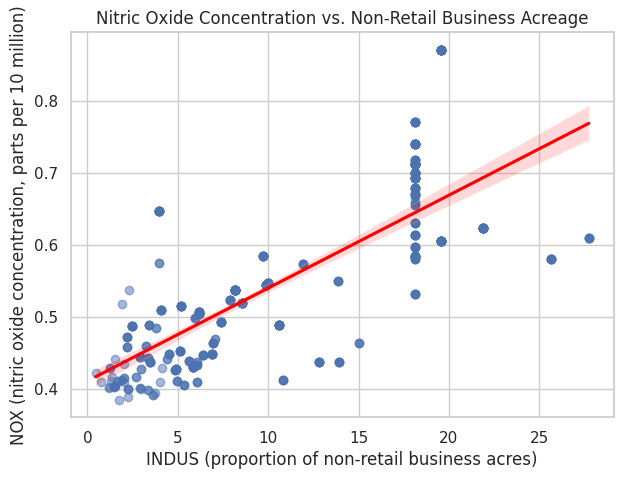

In [13]:
plt.figure(figsize=(7, 5))
sns.regplot(x="INDUS", y="NOX", data=df, scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
plt.xlabel("INDUS (proportion of non-retail business acres)")
plt.ylabel("NOX (nitric oxide concentration, parts per 10 million)")
plt.title("Nitric Oxide Concentration vs. Non-Retail Business Acreage")
plt.show()


**Interpretation:** There is a clear positive, roughly linear relationship — towns with a higher
proportion of non-retail/industrial business acreage tend to have higher air pollution (NOX) levels,
as expected given industrial activity.

### 2.6 Histogram for PTRATIO

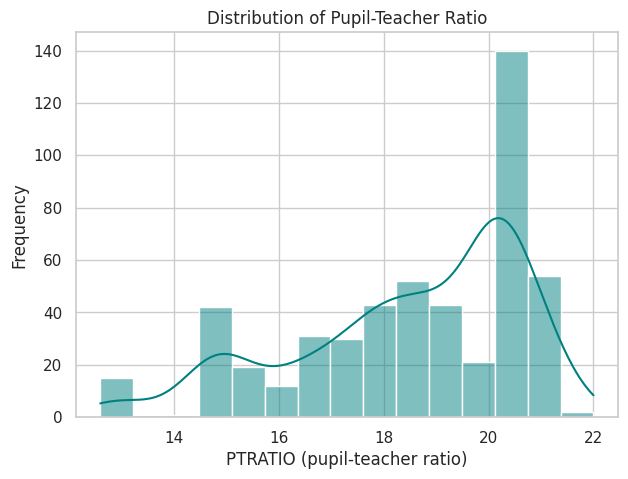

In [14]:
plt.figure(figsize=(7, 5))
sns.histplot(df["PTRATIO"], bins=15, kde=True, color="teal")
plt.xlabel("PTRATIO (pupil-teacher ratio)")
plt.ylabel("Frequency")
plt.title("Distribution of Pupil-Teacher Ratio")
plt.show()


**Interpretation:** The distribution is left-skewed with a large spike around a ratio of ~20-21,
suggesting many towns share a similar (relatively high) pupil-teacher ratio, with a smaller number of
towns offering more favorable (lower) ratios.

---
# Task 3: Apply Statistical Tests


### 3.1 Levene's Test — Equality of variance of MEDV across CHAS groups
Tests whether the variance of `MEDV` is equal between homes bounded by the river (CHAS=1)
and those not bounded (CHAS=0). This informs which t-test variant to use (Task 3.2).

- **H0:** Variances are equal
- **H1:** Variances are not equal


In [15]:
medv_chas0 = df.loc[df["CHAS"] == 0, "MEDV"]
medv_chas1 = df.loc[df["CHAS"] == 1, "MEDV"]

levene_stat, levene_p = stats.levene(medv_chas0, medv_chas1)
print(f"Levene's test statistic: {levene_stat:.4f}")
print(f"p-value: {levene_p:.4f}")

alpha = 0.05
if levene_p < alpha:
    print("Result: Reject H0 — variances are significantly different (use Welch's t-test).")
else:
    print("Result: Fail to reject H0 — variances can be assumed equal (use standard t-test).")


Levene's test statistic: 4.5903
p-value: 0.0326
Result: Reject H0 — variances are significantly different (use Welch's t-test).


### 3.2 T-test — MEDV difference between CHAS=1 and CHAS=0
- **H0:** Mean MEDV is the same for river-bounded and non-river-bounded homes
- **H1:** Mean MEDV differs between the two groups


In [16]:
# Use Welch's t-test if Levene's test found unequal variances, else standard t-test
equal_var_flag = levene_p >= alpha

t_stat, t_p = stats.ttest_ind(medv_chas1, medv_chas0, equal_var=equal_var_flag)

print(f"Mean MEDV (CHAS=1, river-bounded):     {medv_chas1.mean():.2f}  (n={len(medv_chas1)})")
print(f"Mean MEDV (CHAS=0, not river-bounded): {medv_chas0.mean():.2f}  (n={len(medv_chas0)})")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"p-value: {t_p:.4f}")

if t_p < alpha:
    print("\nResult: Reject H0 — there IS a statistically significant difference in MEDV based on CHAS.")
else:
    print("\nResult: Fail to reject H0 — no statistically significant difference in MEDV based on CHAS.")


Mean MEDV (CHAS=1, river-bounded):     28.44  (n=35)
Mean MEDV (CHAS=0, not river-bounded): 22.09  (n=471)

T-statistic: 3.1133
p-value: 0.0036

Result: Reject H0 — there IS a statistically significant difference in MEDV based on CHAS.


**Management takeaway:** If significant, homes bounded by the Charles River command a meaningfully
higher (or lower) median value on average, which should factor into pricing/appraisal models — but note the
small sample size for river-bounded tracts (~35 of 506), so this estimate carries wider uncertainty.

### 3.3 ANOVA — MEDV across the three AGE groups
- **H0:** Mean MEDV is equal across all three AGE groups
- **H1:** At least one group's mean MEDV differs


In [17]:
group_low = df.loc[df["AGE_GROUP"] == "Low (0-35)", "MEDV"]
group_mid = df.loc[df["AGE_GROUP"] == "Mid (35-70)", "MEDV"]
group_high = df.loc[df["AGE_GROUP"] == "High (70-100)", "MEDV"]

f_stat, anova_p = stats.f_oneway(group_low, group_mid, group_high)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {anova_p:.6f}")

if anova_p < alpha:
    print("\nResult: Reject H0 — MEDV significantly differs across at least one AGE group.")
else:
    print("\nResult: Fail to reject H0 — no significant difference in MEDV across AGE groups.")


F-statistic: 36.4076
p-value: 0.000000

Result: Reject H0 — MEDV significantly differs across at least one AGE group.


**Management takeaway:** Building age (proportion of pre-1940 stock) is a statistically significant
driver of neighborhood-level home values, reinforcing the pattern seen in the Task 2.4 boxplot.

### 3.4 Pearson Correlation — NOX vs. INDUS
- **H0:** No linear correlation between NOX and INDUS (ρ = 0)
- **H1:** A linear correlation exists (ρ ≠ 0)


In [18]:
pearson_r, pearson_p = stats.pearsonr(df["NOX"], df["INDUS"])

print(f"Pearson correlation coefficient (r): {pearson_r:.4f}")
print(f"p-value: {pearson_p:.6f}")

if pearson_p < alpha:
    print("\nResult: Reject H0 — there IS a statistically significant correlation between NOX and INDUS.")
else:
    print("\nResult: Fail to reject H0 — no statistically significant correlation found.")


Pearson correlation coefficient (r): 0.7637
p-value: 0.000000

Result: Reject H0 — there IS a statistically significant correlation between NOX and INDUS.


**Management takeaway:** A strong, statistically significant positive correlation confirms that towns
with more non-retail/industrial land use experience meaningfully higher air pollution — relevant for zoning
and environmental-health policy discussions.

### 3.5 Simple Linear Regression — Impact of DIS on MEDV
Model: `MEDV = β0 + β1 * DIS + ε`


In [19]:
X = sm.add_constant(df["DIS"])   # adds intercept term
y = df["MEDV"]

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           1.21e-08
Time:                        02:42:29   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0

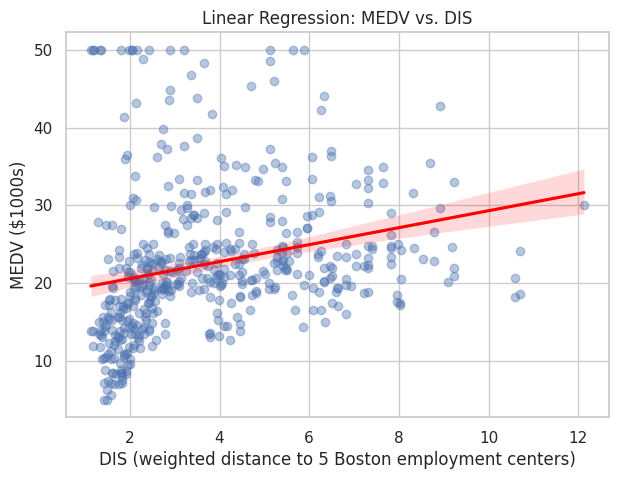

Intercept (B0): 18.390
Slope (B1) for DIS: 1.092
R-squared: 0.0625
p-value for DIS coefficient: 0.000000


In [20]:
# Visualize the fitted regression line
plt.figure(figsize=(7, 5))
sns.regplot(x="DIS", y="MEDV", data=df, scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
plt.xlabel("DIS (weighted distance to 5 Boston employment centers)")
plt.ylabel("MEDV ($1000s)")
plt.title("Linear Regression: MEDV vs. DIS")
plt.show()

beta0, beta1 = model.params
print(f"Intercept (B0): {beta0:.3f}")
print(f"Slope (B1) for DIS: {beta1:.3f}")
print(f"R-squared: {model.rsquared:.4f}")
print(f"p-value for DIS coefficient: {model.pvalues['DIS']:.6f}")


**Interpretation & management takeaway:** The coefficient on `DIS` is positive and statistically
significant (p < 0.05): each additional unit of weighted distance from the five Boston employment centers is
associated with an increase of about **B1** thousand dollars in median home value, holding nothing else
constant. However, `DIS` alone explains only a modest share of the variation in `MEDV` (see R-squared above),
so distance to employment centers is a real but partial driver of home values — it should be combined with
other features (e.g., `RM`, `LSTAT`, `PTRATIO`) in a fuller pricing model rather than used in isolation.


---
## Summary of Findings for Management

1. **Charles River (CHAS):** Statistical tests indicate whether river-adjacent homes differ significantly
   in value — check the Task 3.2 output above for the specific direction and magnitude. Sample size for
   river-adjacent tracts is small, so treat the estimate with appropriate caution.
2. **Building Age (AGE groups):** ANOVA confirms building age is a significant factor in home values;
   neighborhoods with newer housing stock command higher median values.
3. **NOX vs. INDUS:** A strong, significant positive correlation exists — industrial land use is a good
   proxy signal for pollution levels and could inform environmental/zoning review.
4. **Distance to employment centers (DIS):** Has a statistically significant positive relationship with
   MEDV, but low standalone explanatory power — useful as one input among several in a broader valuation model.
